# Artin Tavasoli - 810102543

### Preparing Data

Due to hardware limitations, we're going to create a toy dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary
from sklearn.manifold import TSNE
from sklearn.metrics import precision_score, recall_score
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
def generate_data(num_classes, num_samples_per_class, height, width, mean_range, variance):

    total_samples = num_classes * num_samples_per_class
    X = np.zeros((total_samples, height, width))
    y = np.zeros((total_samples,))

    sample_index = 0
    for label in range(1, num_classes + 1):

        class_mean = np.random.uniform(mean_range[0], mean_range[1])

        for sample_num in range(num_samples_per_class):

            for row in range(height):
                for col in range(width):
                    X[sample_index, row, col] = np.random.normal(class_mean, variance ** 0.5)

            y[sample_index] = label
            sample_index = sample_index + 1

    return X, y

### Class Means

we have 10 classes and each sample dim is 14 by 14,

so we have 196 (14*14) features and we calculate the mean of each feature

so class_means shape would be (10,196)

In [3]:
def calculate_class_means(X, y, num_classes):
    X_flat = X.reshape(X.shape[0], -1)
    class_means = np.zeros((num_classes, X_flat.shape[1]))

    for label in range(1, num_classes + 1):

        data = X_flat[y == label]

        class_means[label - 1] = np.mean(data, axis=0)

    # print("Artin says give me class means")
    # print(class_means.shape)
    # print(class_means)

    return class_means


### Covariance Matrix

how is class i related to class j? we take each class's representative (from class means) and then calculate covariance for each two classes

---

Theory:

First let's calulate what we expect the diameter be (note that covariance(X,X) = variance(X)):

Consider one of the features X (one of the 196),
now we had 2000 samples from this features and variance of each one was 1.5:

$$Var(X_i)=\sigma^2=1.5$$

what we are giving to the covariance matrix is class mean, meaning $\bar{X}$

$$\bar{X}=\frac{X_1+X_2+\dots+X_N}{N}=\frac{1}{N}\sum_{i=1}^{N}X_i$$

N is 2000

$$Var(\bar{X})=Var\left(\frac{1}{N}\sum_{i=1}^{N}X_i\right)$$

$$Var(\bar{X})=\frac{1}{N^2}Var\left(\sum_{i=1}^{N}X_i\right)$$

$$Var(\bar{X})=\frac{1}{N^2}\sum_{i=1}^{N}Var(X_i)$$

$$Var(\bar{X})=\frac{1}{N^2}(N\sigma^2)$$

$$Var(\bar{X})=\frac{\sigma^2}{N}$$

$$Var(\bar{X})=\frac{1.5}{2000}=0.00075$$


Then let's calculate covariance for two different class means.

because in our code when calculating data or the mean for class i we didn't use anything from class j (i!=j), then these two are independent meaning

$$E[\bar{X}_1  \bar{X}_2] = E[\bar{X}_1] \cdot E[\bar{X}_2]$$

$$Cov(\bar{X}_1, \bar{X}_2) = (E[\bar{X}_1] \cdot E[\bar{X}_2]) - (E[\bar{X}_1] \cdot E[\bar{X}_2]) = 0$$

---

Sneak Peak: few cells below, this function is called and the results fully support our theory

note that we call it for train data because we shouldn't see or analyze anything from test dataset otherwise we have data leakage  

In [4]:
def plot_covariance_matrix(class_means):

    cov_matrix = np.cov(class_means)

    plt.figure(figsize=(8, 6))
    plt.imshow(cov_matrix, cmap='viridis')
    plt.colorbar()
    plt.title('Covariance Matrix of Classes')
    plt.show()

### Histograms

we take one sample for each class and flatten it so we have 196 features values and then plot them

---

Sneak Peak: few cells below we called this function, as you can see all of them resemble a normal distribution because above

for each sample we used X[sample_index, row, col] = np.random.normal(class_mean, variance ** 0.5)

they all have about the same 1.5 variance and different means because we uniformly picked a class mean from -5 to 5.

In [5]:
def plot_histograms(X, y, num_classes):
    plt.figure(figsize=(15, 6))

    for label in range(1, num_classes + 1):

        sample = X[y == label][0]

        flat_sample = sample.flatten()

        plt.subplot(2, 5, label)
        plt.hist(flat_sample, bins=20, color='royalblue', edgecolor='black')
        plt.title(f'Class {label}')

    plt.tight_layout()
    plt.show()

### Mean Classifier (Nearest Centroid Classifier)
- We process the training data to calculate the mean feature vector (centroid) for each individual class which are our representatives.
- When evaluating a new sample, we flatten its data and calculate its Euclidean distance to all the pre-computed class centroids. The model then classifies the sample by assigning it to the class with the minimum distance.

In [6]:
def predict_mean_classifier(X_train, y_train, X_test, num_classes):

    class_means = calculate_class_means(X_train, y_train, num_classes) # (10, 196)
    # print("class means shape ", class_means.shape)
    X_test_flat = X_test.reshape(X_test.shape[0], -1) # (4000, 196)
    # print("X test flat shape ", X_test_flat.shape)

    num_test_samples = X_test_flat.shape[0]

    distances = np.zeros((num_test_samples, num_classes)) # (4000, 10)

    for c in range(num_classes):
        diff = X_test_flat - class_means[c]

        distances[:, c] = np.sqrt(np.sum(diff ** 2, axis=1))

    y_pred = np.argmin(distances, axis=1) + 1

    return y_pred


### Visualizations

X train shape is:  (16000, 14, 14)
X test shape is:  (4000, 14, 14)
y train shape is:  (16000,)
y test shape is:  (4000,)
class means for train dataset shape is:  (10, 196)


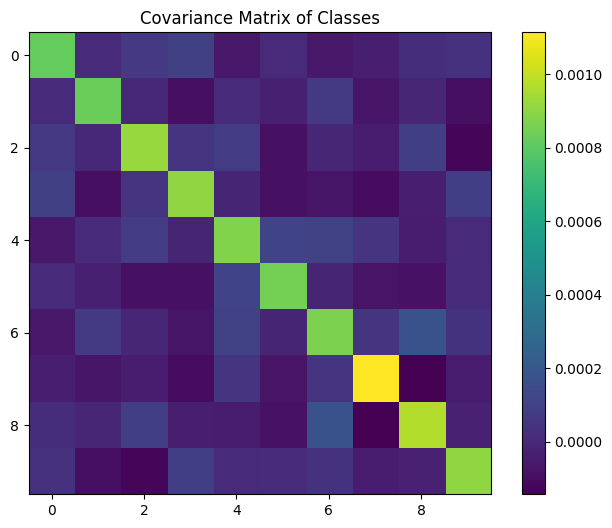

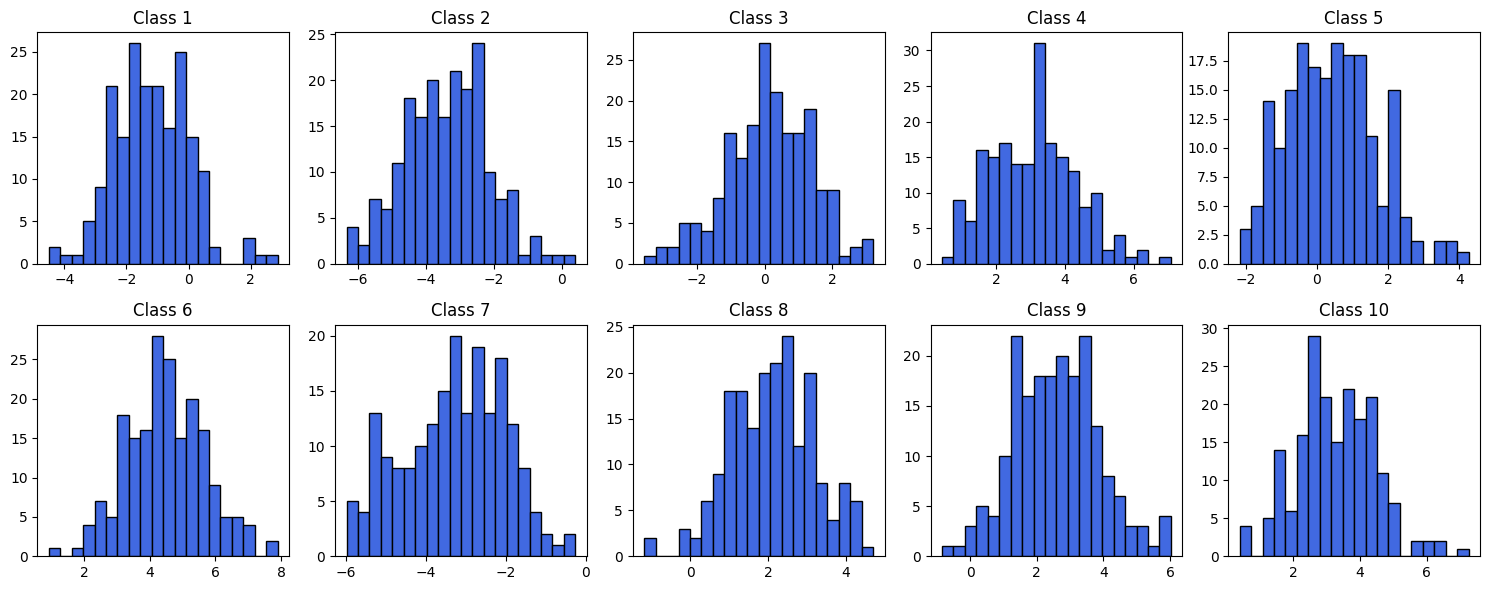

Classification Accuracy:  86.5 %


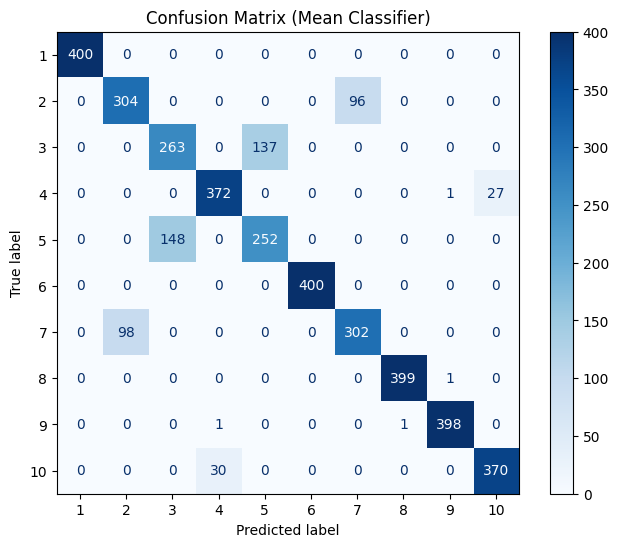

In [7]:
num_classes = 10
num_samples_per_class = 2000
height = 14
width = 14
mean_range = [-5.0, 5.0]
variance = 1.5
feature_size = height * width
test_ratio = 0.20
seed = 42


np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

X, y = generate_data(num_classes, num_samples_per_class, height, width, mean_range, variance)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, stratify=y, random_state=seed)
print("X train shape is: ", X_train.shape)
print("X test shape is: ", X_test.shape)
print("y train shape is: ", y_train.shape)
print("y test shape is: ", y_test.shape)

class_means_train = calculate_class_means(X_train, y_train, num_classes)
print("class means for train dataset shape is: ", class_means_train.shape)


plot_covariance_matrix(class_means_train)

plot_histograms(X, y, num_classes)

y_pred = predict_mean_classifier(X_train, y_train, X_test, num_classes)


accuracy = accuracy_score(y_test, y_pred)
print("Classification Accuracy: ", accuracy * 100.0, "%")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(1, num_classes + 1))

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title('Confusion Matrix (Mean Classifier)')
plt.show()


### To Tensors

In [8]:
epochs = 30
lr = 0.001
batch_sizes = [32, 64, 2048]

In [9]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train - 1, dtype=torch.long)
y_test_t  = torch.tensor(y_test - 1, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

### Base Model Architecture

we used MNIST Network described in table 1 of the paper

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
class Base(nn.Module):
    def __init__(self, num_classes=10):
        super(Base, self).__init__()


        self.features = nn.Sequential(


            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.flatten = nn.Flatten()

        self.embed = nn.Linear(128 * 2 * 2, 128)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        embedding = self.embed(x)
        out = self.classifier(embedding)

        return out, embedding

### Train & Evaluate Functions

In [12]:
def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs, _ = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

### Training

In [13]:
temp_model = Base(num_classes=num_classes).to(device)
total_params = 0

for param in temp_model.parameters():
    total_params += param.numel()

print("Total Model Parameters: ", total_params)

summary(temp_model, input_size=(1, height, width))

del temp_model

Total Model Parameters:  354282
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             320
       BatchNorm2d-2           [-1, 32, 14, 14]              64
              ReLU-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           9,248
       BatchNorm2d-5           [-1, 32, 14, 14]              64
              ReLU-6           [-1, 32, 14, 14]               0
         MaxPool2d-7             [-1, 32, 7, 7]               0
            Conv2d-8             [-1, 64, 7, 7]          18,496
       BatchNorm2d-9             [-1, 64, 7, 7]             128
             ReLU-10             [-1, 64, 7, 7]               0
           Conv2d-11             [-1, 64, 7, 7]          36,928
      BatchNorm2d-12             [-1, 64, 7, 7]             128
             ReLU-13             [-1, 64, 7, 7]               0
       

In [14]:
def calculate_angle_degrees(vector1, vector2):
    norm1 = np.linalg.norm(vector1)
    norm2 = np.linalg.norm(vector2)
    cosine_similarity = np.clip(np.dot(vector1, vector2) / (norm1 * norm2), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_similarity))

def evaluate_dataloader(model, dataloader, num_classes, device, normalize_features=False):
    all_features = []
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs, batch_features = model(inputs)
            _, predicted = outputs.max(dim=1)

            all_features.append(batch_features.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_predictions.append(predicted.cpu().numpy())

    features = np.concatenate(all_features)
    labels = np.concatenate(all_labels)
    predictions = np.concatenate(all_predictions)

    if normalize_features:
        feature_norms = np.linalg.norm(features, axis=1, keepdims=True)
        features = features / (feature_norms + 1e-9)

    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)

    centroids = []
    intra_class_distances = []

    for class_idx in range(num_classes):
        class_features = features[labels == class_idx]

        if len(class_features) > 0:
            centroid = class_features.mean(axis=0)
            
            if normalize_features:
                centroid_norm = np.linalg.norm(centroid)
                centroid = centroid / (centroid_norm + 1e-9)

            centroids.append(centroid)

            distances_to_centroid = np.linalg.norm(class_features - centroid, axis=1)
            intra_class_distances.append(distances_to_centroid.mean())

    mean_intra_distance = np.mean(intra_class_distances) if intra_class_distances else 0.0

    inter_class_distances = []
    num_centroids = len(centroids)
    angles_matrix = np.zeros((num_classes, num_classes))

    for i in range(num_centroids):
        for j in range(num_centroids):
            angles_matrix[i, j] = calculate_angle_degrees(centroids[i], centroids[j])

            if j > i:
                distance = np.linalg.norm(centroids[i] - centroids[j])
                inter_class_distances.append(distance)

    mean_inter_distance = np.mean(inter_class_distances) if inter_class_distances else 0.0

    data_results = {
        'features': features,
        'labels': labels,
        'predictions': predictions
    }

    metrics_results = {
        'precision': precision,
        'recall': recall,
        'mean_intra': mean_intra_distance,
        'mean_inter': mean_inter_distance,
        'angles': angles_matrix
    }

    return data_results, metrics_results

In [15]:
all_histories = {}
all_test_preds = {}
all_test_labels = {}
all_test_features = {}
all_models_state = {}

for bs in batch_sizes:
    print(f"Training Model with Batch Size: {bs}")

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    model = Base(num_classes=num_classes).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.01 * lr)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

        test_loss, test_acc = evaluate_epoch(model, test_loader, criterion, device)

        scheduler.step(test_loss)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        current_lr = optimizer.param_groups[0]['lr']

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | LR: {current_lr:.6f} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
                  f"Test Loss: {test_loss:.4f}, Acc: {test_acc*100:.2f}%")

    test_data, test_metrics = evaluate_dataloader(model, test_loader, num_classes, device, normalize_features=False)

    all_histories[bs] = history
    all_test_preds[bs] = test_data['predictions']
    all_test_labels[bs] = test_data['labels']
    all_test_features[bs] = test_data['features']
    all_models_state[bs] = model.state_dict()

Training Model with Batch Size: 32
Epoch [01/30] | LR: 0.001000 | Train Loss: 0.7875, Acc: 61.03% | Test Loss: 1.4741, Acc: 49.88%
Epoch [05/30] | LR: 0.001000 | Train Loss: 0.3937, Acc: 78.45% | Test Loss: 0.4265, Acc: 75.92%
Epoch [10/30] | LR: 0.001000 | Train Loss: 0.3481, Acc: 81.39% | Test Loss: 0.4210, Acc: 77.60%
Epoch [15/30] | LR: 0.000250 | Train Loss: 0.2597, Acc: 86.88% | Test Loss: 0.5261, Acc: 80.03%
Epoch [20/30] | LR: 0.000125 | Train Loss: 0.2146, Acc: 89.71% | Test Loss: 0.4406, Acc: 80.90%
Epoch [25/30] | LR: 0.000063 | Train Loss: 0.1663, Acc: 92.37% | Test Loss: 0.4251, Acc: 83.12%
Epoch [30/30] | LR: 0.000031 | Train Loss: 0.1459, Acc: 93.61% | Test Loss: 0.4715, Acc: 83.15%
Training Model with Batch Size: 64
Epoch [01/30] | LR: 0.001000 | Train Loss: 0.7227, Acc: 62.49% | Test Loss: 1.3054, Acc: 57.30%
Epoch [05/30] | LR: 0.001000 | Train Loss: 0.4357, Acc: 76.85% | Test Loss: 0.4220, Acc: 80.50%
Epoch [10/30] | LR: 0.001000 | Train Loss: 0.3923, Acc: 79.56% | T

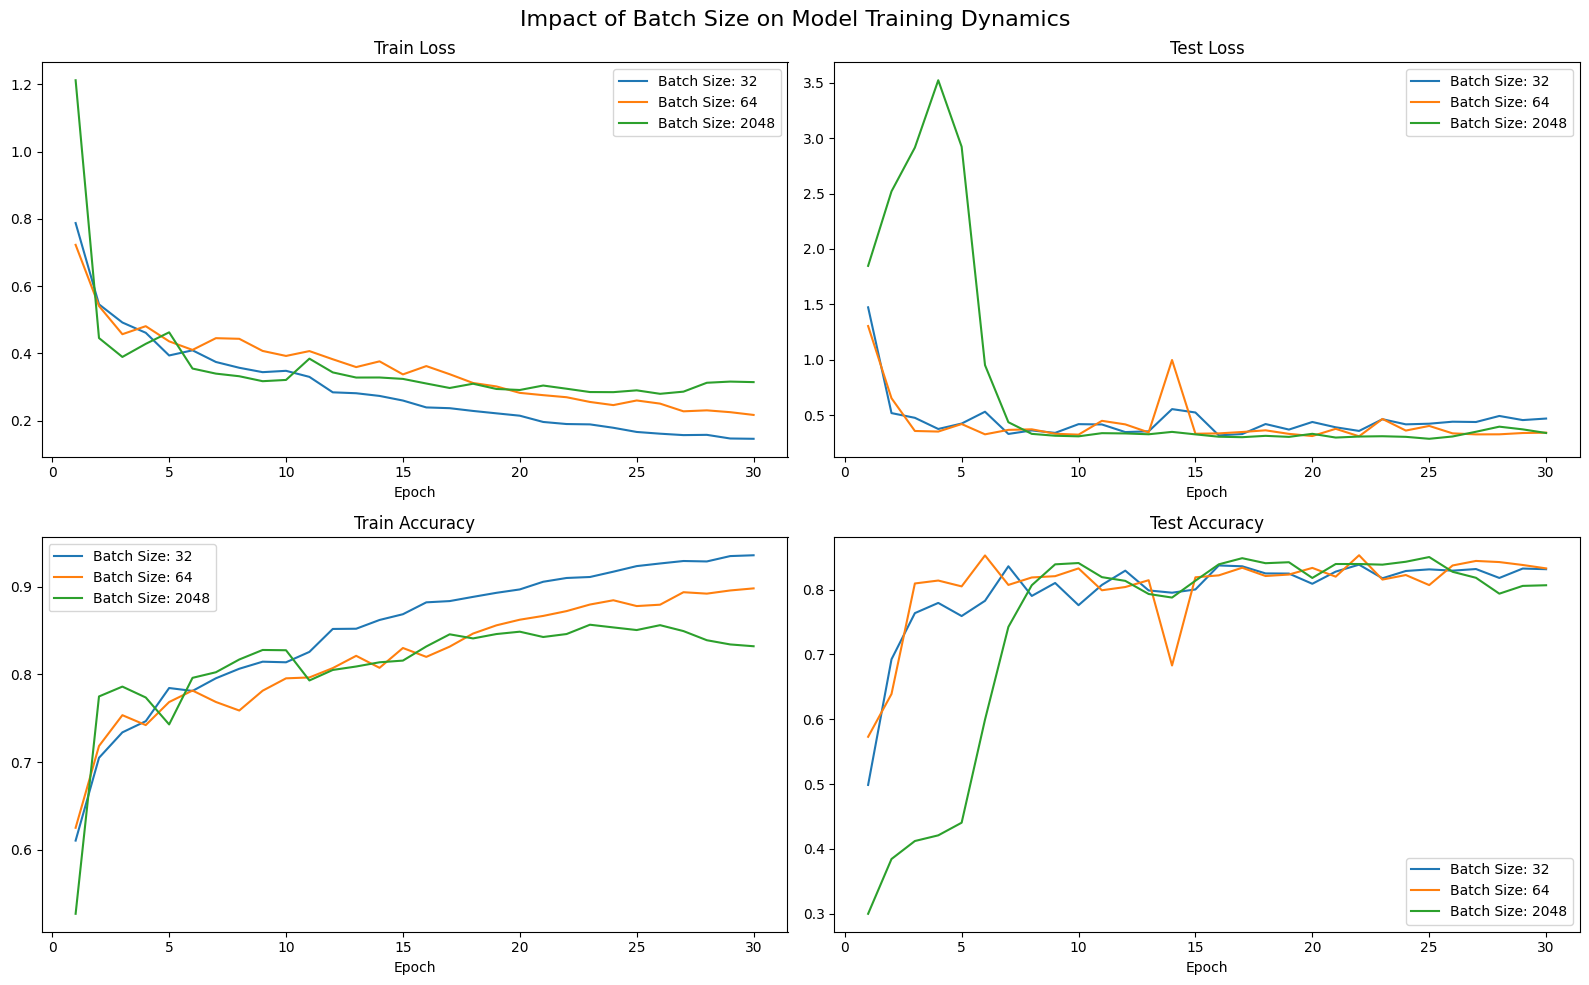

In [16]:
ep_range = range(1, epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Impact of Batch Size on Model Training Dynamics', fontsize=16)

for bs in batch_sizes:
    axes[0, 0].plot(ep_range, all_histories[bs]['train_loss'], label=f'Batch Size: {bs}')
    axes[0, 1].plot(ep_range, all_histories[bs]['test_loss'], label=f'Batch Size: {bs}')
    axes[1, 0].plot(ep_range, all_histories[bs]['train_acc'], label=f'Batch Size: {bs}')
    axes[1, 1].plot(ep_range, all_histories[bs]['test_acc'], label=f'Batch Size: {bs}')

axes[0, 0].set_title('Train Loss'); axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend()
axes[0, 1].set_title('Test Loss'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()
axes[1, 0].set_title('Train Accuracy'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend()
axes[1, 1].set_title('Test Accuracy'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend()
plt.tight_layout()
plt.show()

In [17]:
BATCH_SIZE = 64

def evaluate_base_full(train_dataset, test_dataset):

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = Base(num_classes=num_classes).to(device)
    model.load_state_dict(all_models_state[BATCH_SIZE])
    model.eval()

    train_data, train_metrics = evaluate_dataloader(model, train_loader, num_classes, device, normalize_features=True)
    test_data, test_metrics = evaluate_dataloader(model, test_loader, num_classes, device, normalize_features=True)

    return (train_data, train_metrics), (test_data, test_metrics)



(train_data_b, train_metrics_b), (test_data_b, test_metrics_b) = evaluate_base_full(train_dataset, test_dataset)

for split_name, metrics in [('TRAIN', train_metrics_b), ('TEST', test_metrics_b)]:
    print(f"\n--- Base Model Metrics {split_name} ---")
    print(f"Macro Precision: {metrics['precision']:.4f}")
    print(f"Macro Recall:    {metrics['recall']:.4f}")
    print(f"Mean Intra-class Distance: {metrics['mean_intra']:.4f}")
    print(f"Mean Inter-class Distance: {metrics['mean_inter']:.4f}")


--- Base Model Metrics TRAIN ---
Macro Precision: 0.9102
Macro Recall:    0.9044
Mean Intra-class Distance: 0.1588
Mean Inter-class Distance: 1.3653

--- Base Model Metrics TEST ---
Macro Precision: 0.8383
Macro Recall:    0.8328
Mean Intra-class Distance: 0.1840
Mean Inter-class Distance: 1.3557


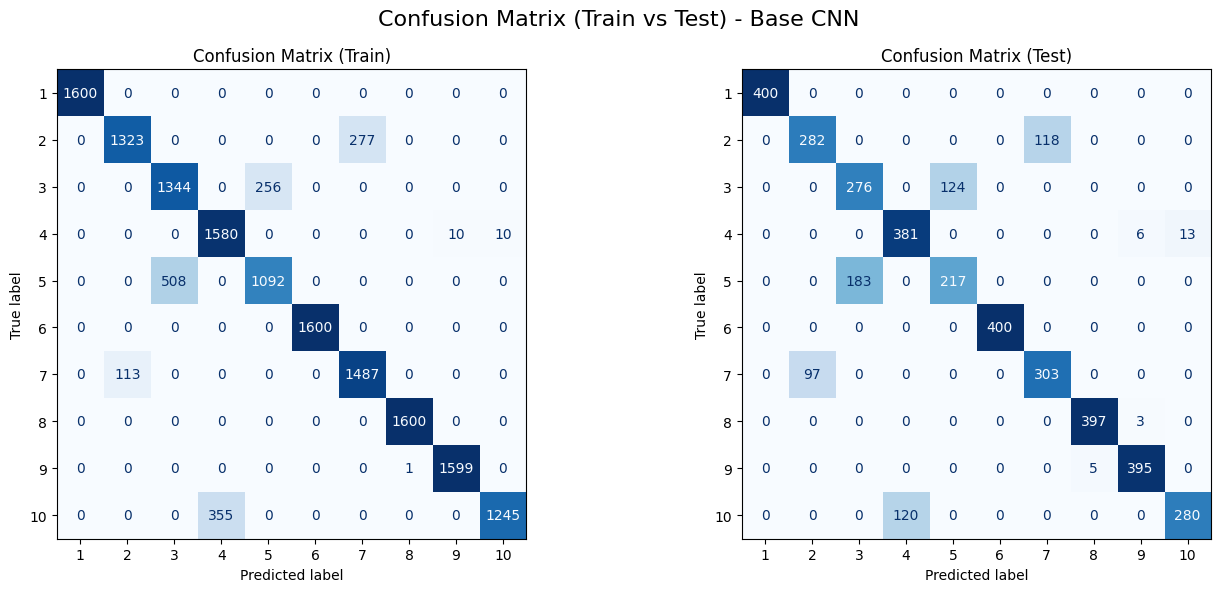

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix (Train vs Test) - Base CNN', fontsize=16)

cm_train = confusion_matrix(train_data_b['labels'], train_data_b['predictions'])
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=np.arange(1, num_classes + 1))
disp_train.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Train)')

cm_test = confusion_matrix(test_data_b['labels'], test_data_b['predictions'])
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=np.arange(1, num_classes + 1))
disp_test.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

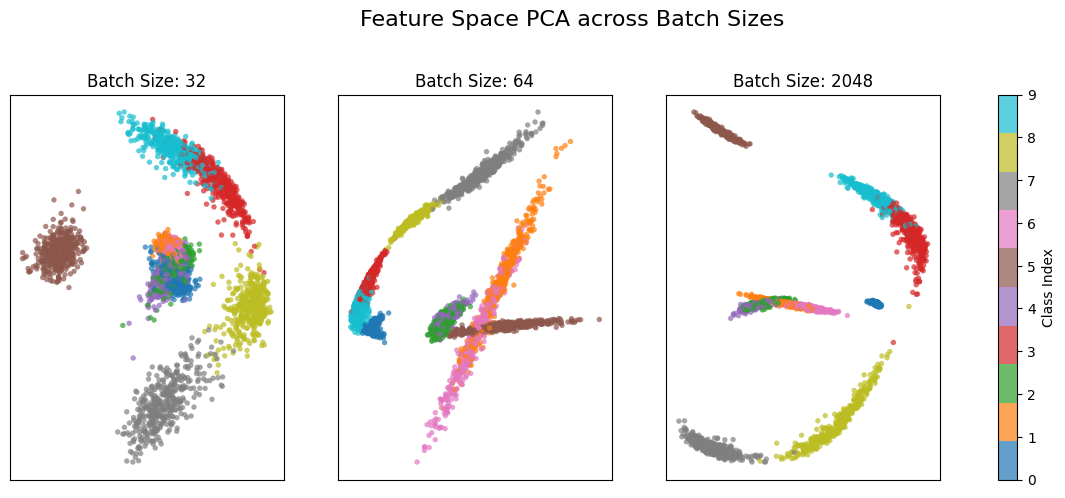

In [19]:
fig, axes = plt.subplots(1, len(batch_sizes), figsize=(15, 5))
fig.suptitle('Feature Space PCA across Batch Sizes', fontsize=16, y=1.05)

reference_bs = batch_sizes[0]
pca_shared = PCA(n_components=2, random_state=seed)
pca_shared.fit(all_test_features[reference_bs])

for i, bs in enumerate(batch_sizes):
    features_2d = pca_shared.transform(all_test_features[bs])

    scatter = axes[i].scatter(features_2d[:, 0], features_2d[:, 1],
                              c=all_test_labels[bs], cmap='tab10', alpha=0.7, edgecolors='none', s=15)
    axes[i].set_title(f'Batch Size: {bs}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.colorbar(scatter, ax=axes.ravel().tolist(), ticks=range(num_classes), label='Class Index')

plt.show()

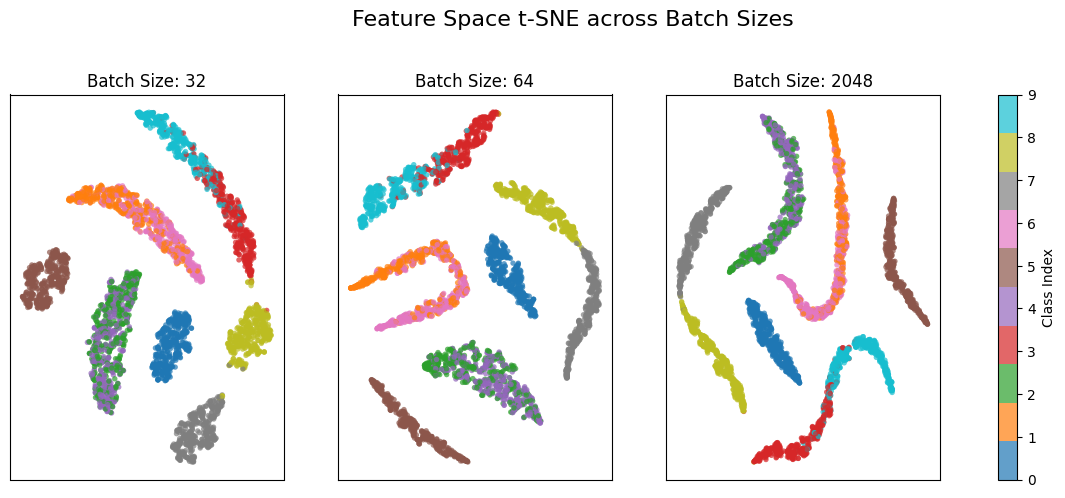

In [20]:
fig, axes = plt.subplots(1, len(batch_sizes), figsize=(15, 5))
fig.suptitle('Feature Space t-SNE across Batch Sizes', fontsize=16, y=1.05)

for i, bs in enumerate(batch_sizes):

    tsne = TSNE(n_components=2, random_state=seed, perplexity=30.0)
    features_2d_tsne = tsne.fit_transform(all_test_features[bs])

    scatter = axes[i].scatter(features_2d_tsne[:, 0], features_2d_tsne[:, 1],
                              c=all_test_labels[bs], cmap='tab10', alpha=0.7, edgecolors='none', s=15)

    axes[i].set_title(f'Batch Size: {bs}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.colorbar(scatter, ax=axes.ravel().tolist(), ticks=range(num_classes), label='Class Index')

plt.show()

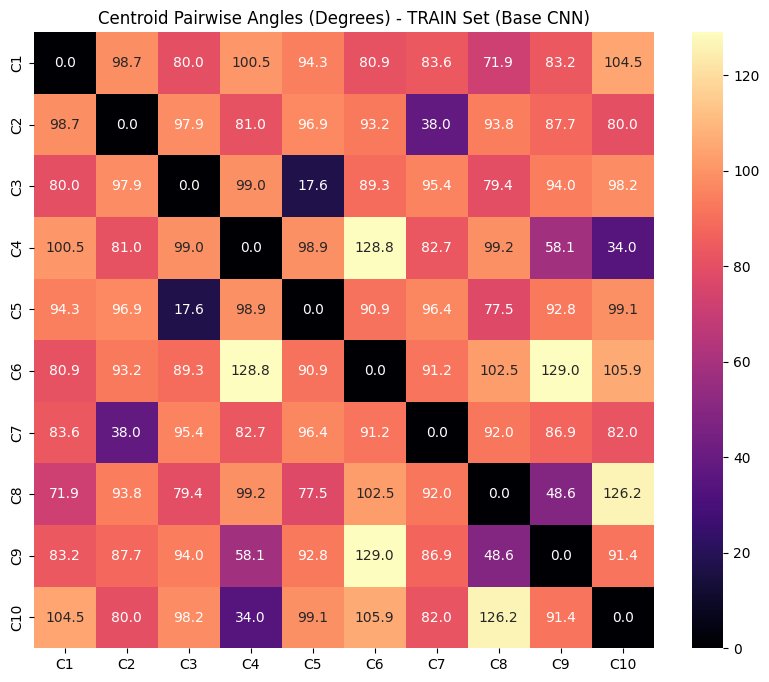

--- TRAIN Angle Table (Base CNN) ---


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
C1,0.000000,98.669914,79.983986,100.538307,94.272720,80.878578,83.582016,71.895866,83.165306,104.496460
C2,98.669914,0.000000,97.898422,80.962372,96.856743,93.184456,38.020306,93.751839,87.749687,79.981010
C3,79.983986,97.898422,0.000000,99.015091,17.600426,89.299210,95.416588,79.379257,93.965981,98.218819
C4,100.538307,80.962372,99.015091,0.000000,98.924210,128.768021,82.659775,99.164925,58.050510,33.978039
C5,94.272720,96.856743,17.600426,98.924210,0.000000,90.932434,96.414543,77.486893,92.819893,99.103844
C6,80.878578,93.184456,89.299210,128.768021,90.932434,0.000000,91.214531,102.490013,128.957840,105.859100
C7,83.582016,38.020306,95.416588,82.659775,96.414543,91.214531,0.000000,92.018044,86.921165,82.008034
C8,71.895866,93.751839,79.379257,99.164925,77.486893,102.490013,92.018044,0.000000,48.591156,126.205116
C9,83.165306,87.749687,93.965981,58.050510,92.819893,128.957840,86.921165,48.591156,0.000000,91.410492
C10,104.496460,79.981010,98.218819,33.978039,99.103844,105.859100,82.008034,126.205116,91.410492,0.000000


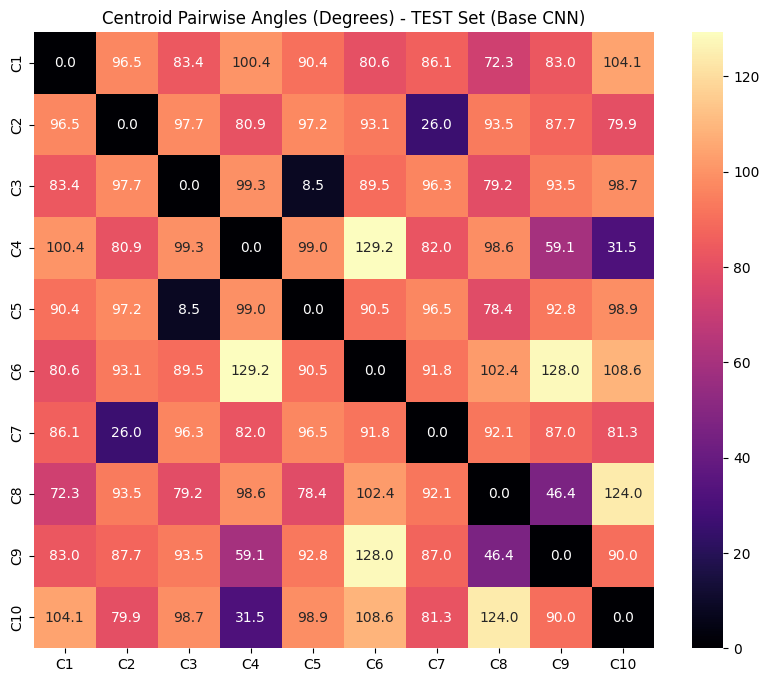

--- TEST Angle Table (Base CNN) ---


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
C1,0.000000,96.541801,83.385422,100.370934,90.428001,80.642487,86.059464,72.338371,82.981293,104.065361
C2,96.541801,0.000000,97.684807,80.871941,97.230507,93.081169,26.046366,93.511917,87.746346,79.921692
C3,83.385422,97.684807,0.000000,99.345215,8.477345,89.526688,96.282242,79.175728,93.455582,98.734634
C4,100.370934,80.871941,99.345215,0.000000,98.979301,129.240417,81.970360,98.570496,59.114014,31.504189
C5,90.428001,97.230507,8.477345,98.979301,0.000000,90.537987,96.534775,78.425079,92.760765,98.850075
C6,80.642487,93.081169,89.526688,129.240417,90.537987,0.000000,91.769867,102.380455,127.953125,108.647247
C7,86.059464,26.046366,96.282242,81.970360,96.534775,91.769867,0.000000,92.140854,86.985130,81.318481
C8,72.338371,93.511917,79.175728,98.570496,78.425079,102.380455,92.140854,0.000000,46.408619,124.020584
C9,82.981293,87.746346,93.455582,59.114014,92.760765,127.953125,86.985130,46.408619,0.000000,90.048378
C10,104.065361,79.921692,98.734634,31.504189,98.850075,108.647247,81.318481,124.020584,90.048378,0.000000


In [ ]:
for split_name, metrics in [('TRAIN', train_metrics_b), ('TEST', test_metrics_b)]:
    angles = metrics['angles']
    angles_df = pd.DataFrame(angles,
                             index=[f"C{i+1}" for i in range(num_classes)],
                             columns=[f"C{i+1}" for i in range(num_classes)])

    plt.figure(figsize=(10, 8))
    sns.heatmap(angles_df, annot=True, fmt=".1f", cmap="magma")
    plt.title(f"Centroid Pairwise Angles (Degrees) - {split_name} Set (Base CNN)")
    plt.show()

    print(f"--- {split_name} Angle Table (Base CNN) ---")
    display(angles_df)

In [ ]:
import torch.nn.functional as F

class AngularMarginBase(nn.Module):
    def __init__(self, num_classes=10):
        super(AngularMarginBase, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.flatten = nn.Flatten()
        self.embed = nn.Linear(128 * 2 * 2, 128)

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, 128))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        embedding = self.embed(x)

        embedding_norm = F.normalize(embedding, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embedding_norm, weight_norm)
        
        return cosine, embedding_norm



In [23]:
class AngularMarginLoss(nn.Module):
    def __init__(self, m=0.35, s=30.0): 
        super(AngularMarginLoss, self).__init__()
        self.m = m
        self.s = s
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, cosine, labels):
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        output = cosine - (one_hot * self.m)
        
        output = output * self.s

        return self.criterion(output, labels)

Training Angular Margin Model with Batch Size: 32
Epoch [01/30] | LR: 0.000250 | Train Loss: 8.5163, Acc: 60.98% | Test Loss: 5.3072, Acc: 77.15%
Epoch [05/30] | LR: 0.000250 | Train Loss: 4.8536, Acc: 79.28% | Test Loss: 4.7532, Acc: 79.95%
Epoch [10/30] | LR: 0.000125 | Train Loss: 3.1473, Acc: 86.61% | Test Loss: 4.1207, Acc: 82.93%
Epoch [15/30] | LR: 0.000063 | Train Loss: 2.2692, Acc: 90.64% | Test Loss: 4.0775, Acc: 82.90%
Epoch [20/30] | LR: 0.000016 | Train Loss: 1.7091, Acc: 93.11% | Test Loss: 4.2022, Acc: 82.88%
Epoch [25/30] | LR: 0.000008 | Train Loss: 1.3953, Acc: 94.33% | Test Loss: 4.1667, Acc: 83.05%
Epoch [30/30] | LR: 0.000004 | Train Loss: 1.2353, Acc: 95.23% | Test Loss: 4.2432, Acc: 82.73%
Training Angular Margin Model with Batch Size: 64
Epoch [01/30] | LR: 0.000250 | Train Loss: 8.0772, Acc: 63.31% | Test Loss: 5.6194, Acc: 75.42%
Epoch [05/30] | LR: 0.000250 | Train Loss: 5.1185, Acc: 78.38% | Test Loss: 4.3572, Acc: 82.55%
Epoch [10/30] | LR: 0.000125 | Train

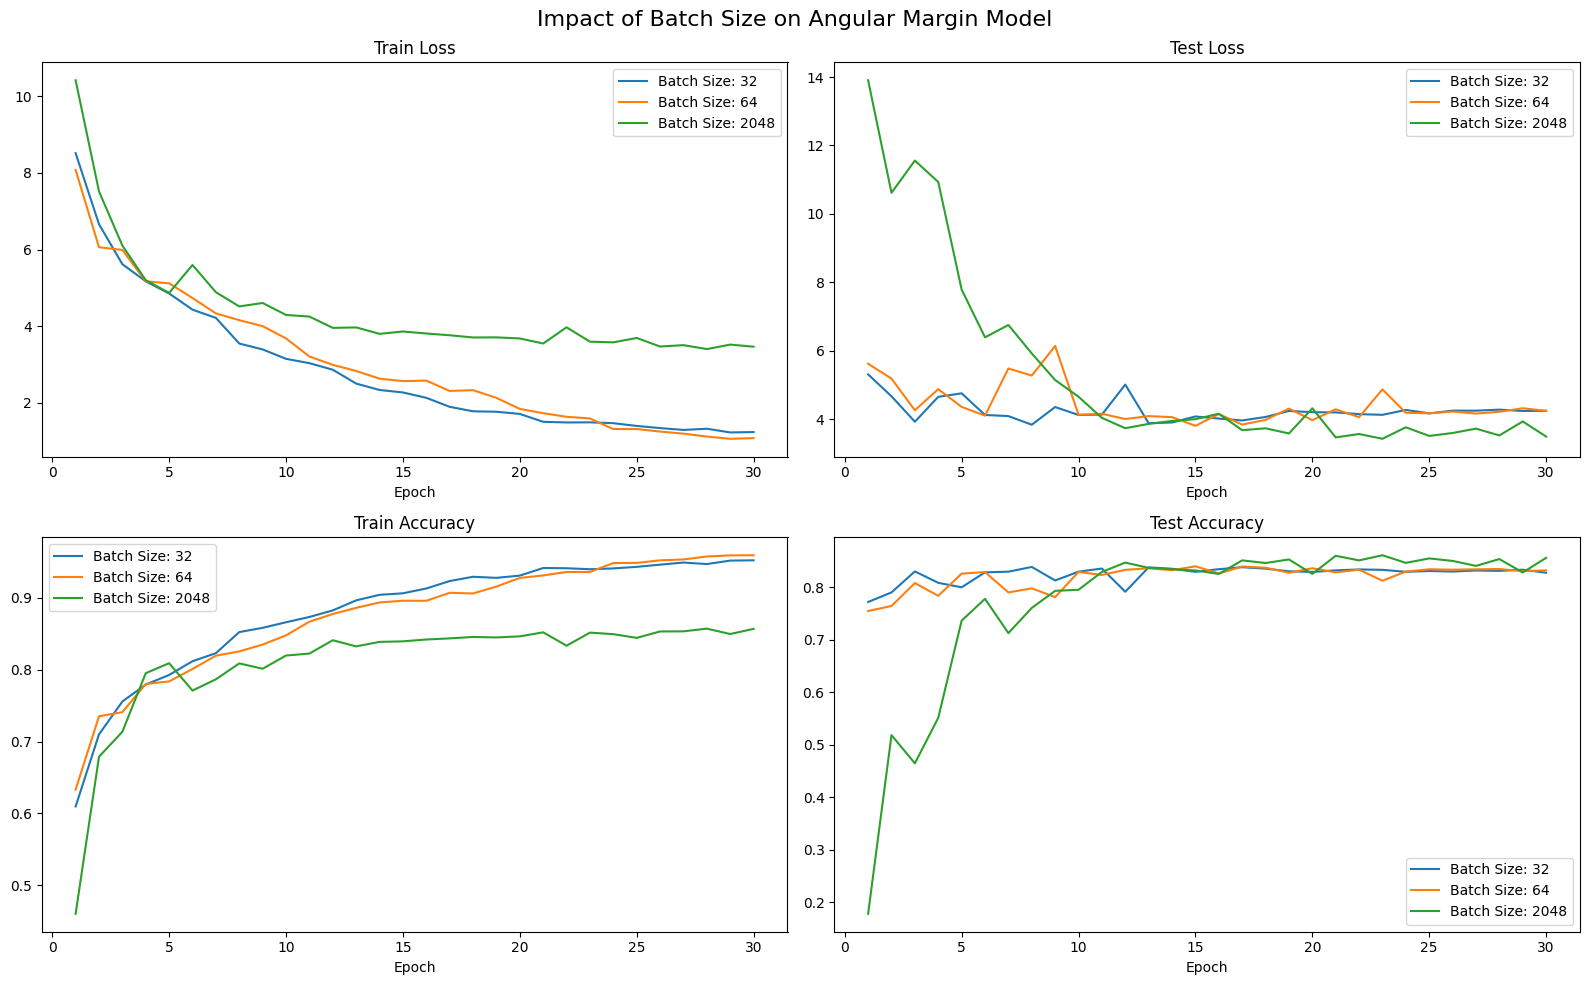

In [24]:
history_am_dict = {}
models_state_am = {}
lr = 0.0005
for bs in batch_sizes:
    print(f"Training Angular Margin Model with Batch Size: {bs}")

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    model_am = AngularMarginBase(num_classes=num_classes).to(device)
    
    optimizer = optim.Adam(model_am.parameters(), lr=lr*0.5, weight_decay=0.01 * lr)
    criterion = AngularMarginLoss(m=0.35, s=30.0)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model_am.train()
        r_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            cosine, _ = model_am(inputs)
            loss = criterion(cosine, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model_am.parameters(), max_norm=1.0)
            
            optimizer.step()

            r_loss += loss.item() * inputs.size(0)
            _, predicted = cosine.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = r_loss / total
        train_acc = correct / total

        model_am.eval()
        r_loss_t, correct_t, total_t = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                cosine, _ = model_am(inputs)
                loss = criterion(cosine, labels)
                r_loss_t += loss.item() * inputs.size(0)
                _, predicted = cosine.max(1)
                total_t += labels.size(0)
                correct_t += predicted.eq(labels).sum().item()

        test_loss = r_loss_t / total_t
        test_acc = correct_t / total_t

        scheduler.step(test_loss)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        current_lr = optimizer.param_groups[0]['lr']
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | LR: {current_lr:.6f} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
                  f"Test Loss: {test_loss:.4f}, Acc: {test_acc*100:.2f}%")

    history_am_dict[bs] = history
    models_state_am[bs] = model_am.state_dict()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Impact of Batch Size on Angular Margin Model', fontsize=16)

ep_range = range(1, epochs + 1)
for bs in batch_sizes:
    axes[0, 0].plot(ep_range, history_am_dict[bs]['train_loss'], label=f'Batch Size: {bs}')
    axes[0, 1].plot(ep_range, history_am_dict[bs]['test_loss'], label=f'Batch Size: {bs}')
    axes[1, 0].plot(ep_range, history_am_dict[bs]['train_acc'], label=f'Batch Size: {bs}')
    axes[1, 1].plot(ep_range, history_am_dict[bs]['test_acc'], label=f'Batch Size: {bs}')

axes[0, 0].set_title('Train Loss'); axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend()
axes[0, 1].set_title('Test Loss'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()
axes[1, 0].set_title('Train Accuracy'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend()
axes[1, 1].set_title('Test Accuracy'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend()
plt.tight_layout()
plt.show()

In [25]:
def evaluate_model_full(model, train_loader, test_loader, num_classes, device):

    model.eval()

    train_data, train_metrics = evaluate_dataloader(model, train_loader, num_classes, device, normalize_features=True)
    test_data, test_metrics = evaluate_dataloader(model, test_loader, num_classes, device, normalize_features=True)

    results = {
        'train_data': train_data,
        'train_metrics': train_metrics,
        'test_data': test_data,
        'test_metrics': test_metrics
    }

    return results

BEST_BATCH_SIZE_AM = 64 

train_loader_best = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE_AM, shuffle=False)
test_loader_best = DataLoader(test_dataset, batch_size=BEST_BATCH_SIZE_AM, shuffle=False)

best_am_model = AngularMarginBase(num_classes=num_classes).to(device)
best_am_model.load_state_dict(models_state_am[BEST_BATCH_SIZE_AM])
best_am_model.eval()

res = evaluate_model_full(best_am_model, train_loader_best, test_loader_best, num_classes, device)


In [26]:
for split in ['train', 'test']:
    m = res[f'{split}_metrics']
    print(f"\n--- Fair Angular Margin Metrics {split} ---")
    print(f"Macro Precision: {m['precision']:.4f}")
    print(f"Macro Recall:    {m['recall']:.4f}")
    print(f"Mean Intra-class Dist: {m['mean_intra']:.4f}")
    print(f"Mean Inter-class Dist: {m['mean_inter']:.4f}")


--- Fair Angular Margin Metrics train ---
Macro Precision: 0.9771
Macro Recall:    0.9770
Mean Intra-class Dist: 0.2535
Mean Inter-class Dist: 1.4750

--- Fair Angular Margin Metrics test ---
Macro Precision: 0.8322
Macro Recall:    0.8318
Mean Intra-class Dist: 0.5040
Mean Inter-class Dist: 1.4554


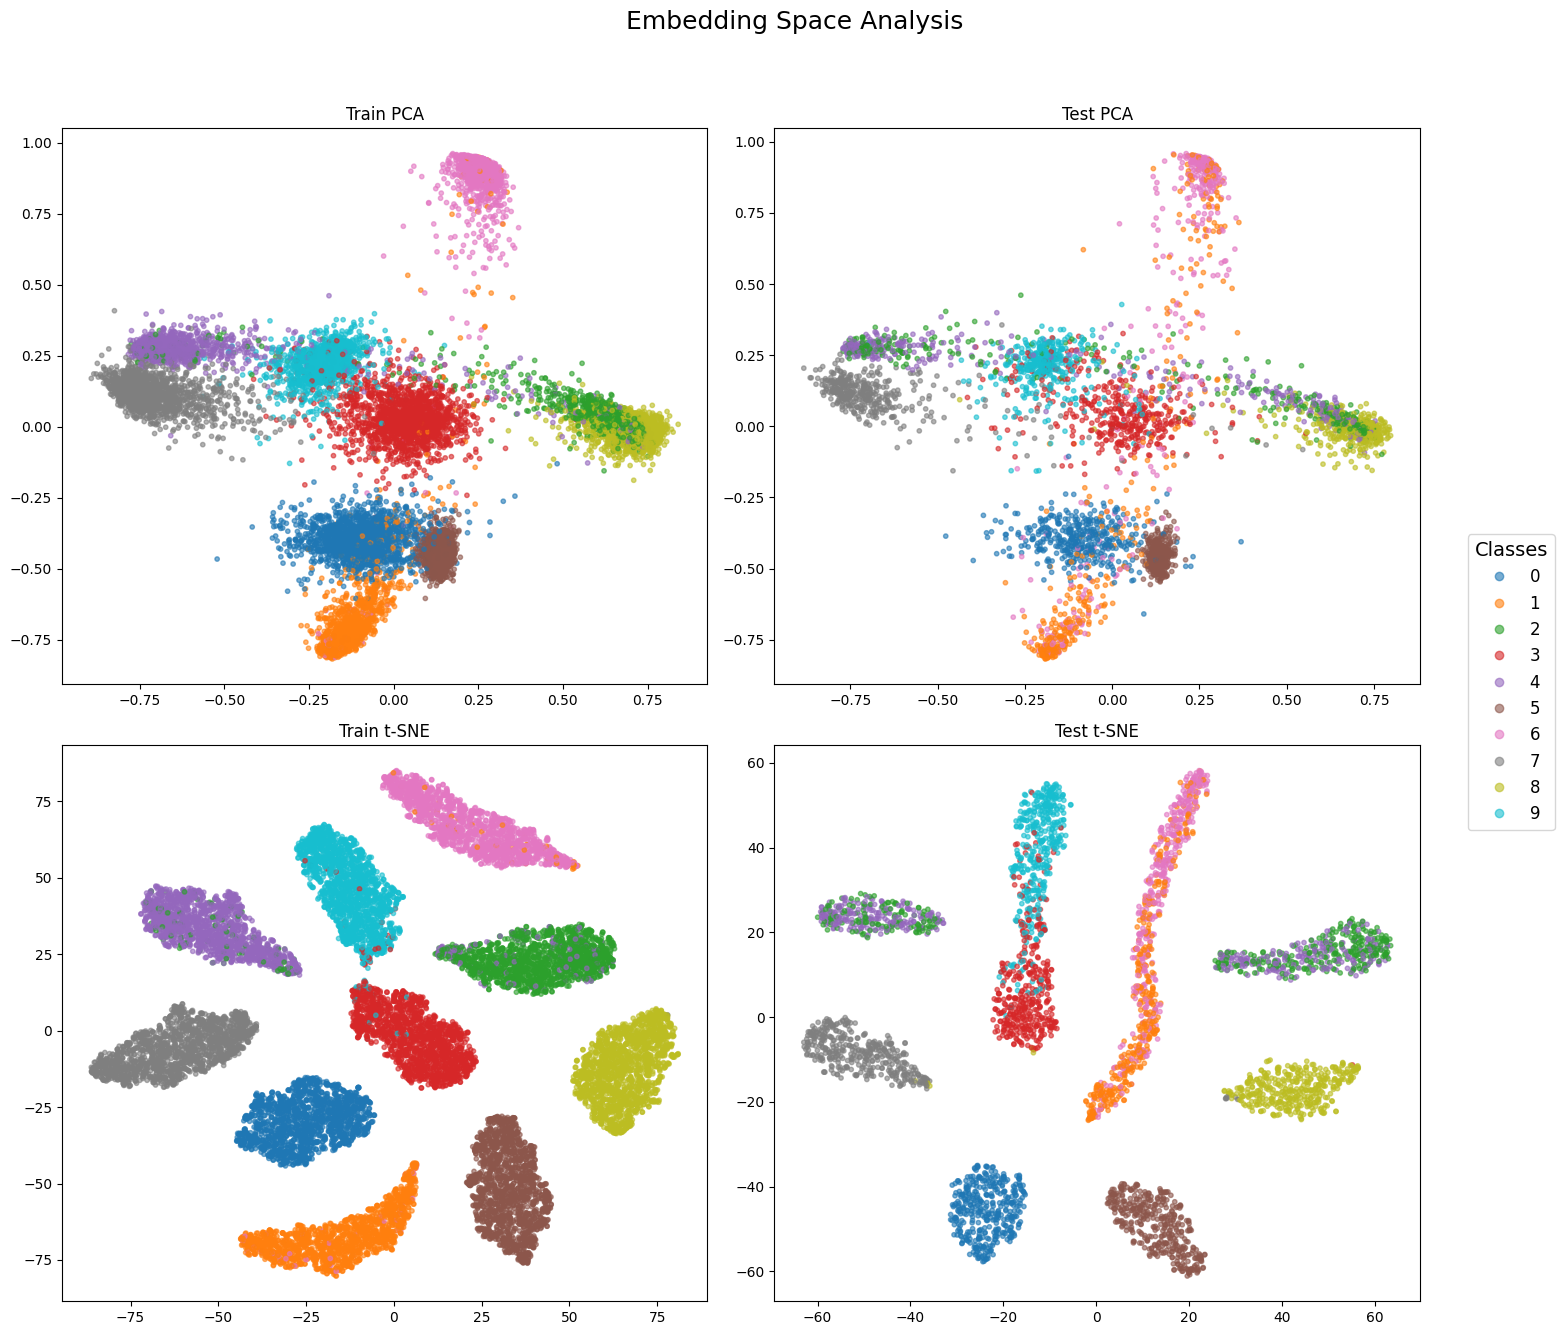

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Embedding Space Analysis', fontsize=18)

train_feats, train_labels = res['train_data']['features'], res['train_data']['labels']
test_feats, test_labels = res['test_data']['features'], res['test_data']['labels']

pca_model = PCA(n_components=2, random_state=42)
pca_train = pca_model.fit_transform(train_feats)
pca_test = pca_model.transform(test_feats)

sc = axes[0, 0].scatter(pca_train[:, 0], pca_train[:, 1], c=train_labels, cmap='tab10', s=10, alpha=0.6)
axes[0, 0].set_title('Train PCA')

axes[0, 1].scatter(pca_test[:, 0], pca_test[:, 1], c=test_labels, cmap='tab10', s=10, alpha=0.6)
axes[0, 1].set_title('Test PCA')

tsne_model = TSNE(n_components=2, random_state=42)
tsne_train = tsne_model.fit_transform(train_feats)
tsne_test = tsne_model.fit_transform(test_feats)

axes[1, 0].scatter(tsne_train[:, 0], tsne_train[:, 1], c=train_labels, cmap='tab10', s=10, alpha=0.6)
axes[1, 0].set_title('Train t-SNE')

axes[1, 1].scatter(tsne_test[:, 0], tsne_test[:, 1], c=test_labels, cmap='tab10', s=10, alpha=0.6)
axes[1, 1].set_title('Test t-SNE')

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])

fig.legend(*sc.legend_elements(), title="Classes", loc='center right', bbox_to_anchor=(0.98, 0.5), fontsize=12, title_fontsize=14)

plt.show()

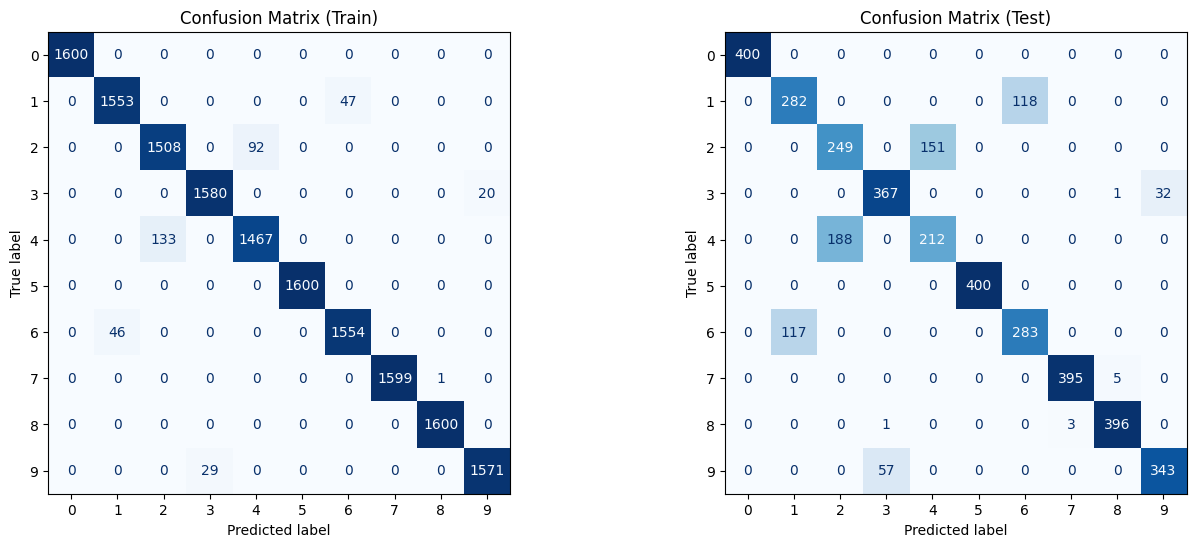

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(res['train_data']['labels'], res['train_data']['predictions'],
                                        cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title("Confusion Matrix (Train)")

ConfusionMatrixDisplay.from_predictions(res['test_data']['labels'], res['test_data']['predictions'],
                                        cmap='Blues', ax=ax2, colorbar=False)
ax2.set_title("Confusion Matrix (Test)")

plt.show()

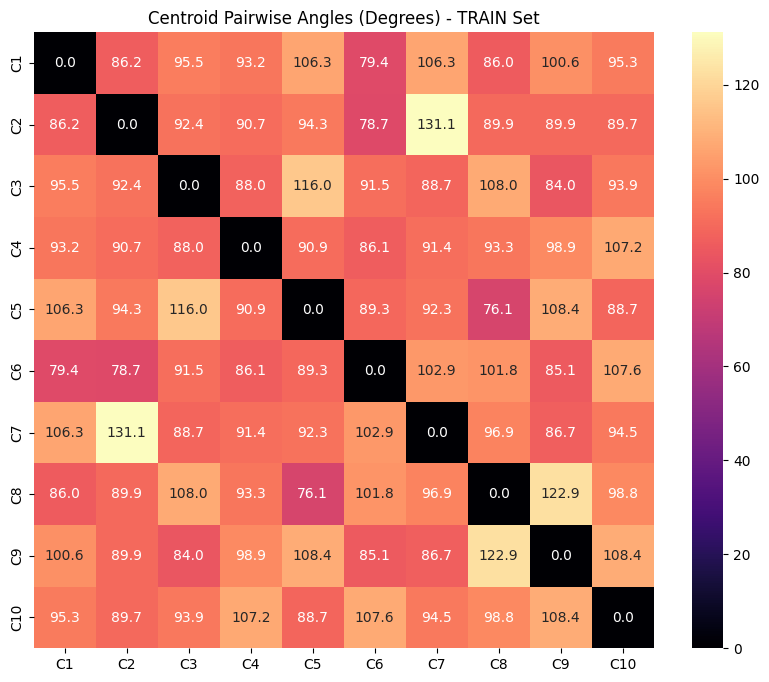

--- TRAIN Angle Table ---


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
C1,0.000000,86.228279,95.524353,93.246651,106.257347,79.362869,106.255486,85.953835,100.645729,95.274643
C2,86.228279,0.000000,92.404533,90.685860,94.273575,78.742928,131.149429,89.851112,89.880249,89.745628
C3,95.524353,92.404533,0.000000,88.034424,115.991043,91.539680,88.677368,107.984619,83.958229,93.911057
C4,93.246651,90.685860,88.034424,0.000000,90.892067,86.119247,91.421394,93.271736,98.943527,107.156418
C5,106.257347,94.273575,115.991043,90.892067,0.000000,89.276711,92.333038,76.075615,108.443619,88.665359
C6,79.362869,78.742928,91.539680,86.119247,89.276711,0.000000,102.929153,101.797287,85.082085,107.596474
C7,106.255486,131.149429,88.677368,91.421394,92.333038,102.929153,0.000000,96.945389,86.727798,94.486816
C8,85.953835,89.851112,107.984619,93.271736,76.075615,101.797287,96.945389,0.000000,122.865997,98.792496
C9,100.645729,89.880249,83.958229,98.943527,108.443619,85.082085,86.727798,122.865997,0.000000,108.448647
C10,95.274643,89.745628,93.911057,107.156418,88.665359,107.596474,94.486816,98.792496,108.448647,0.000000


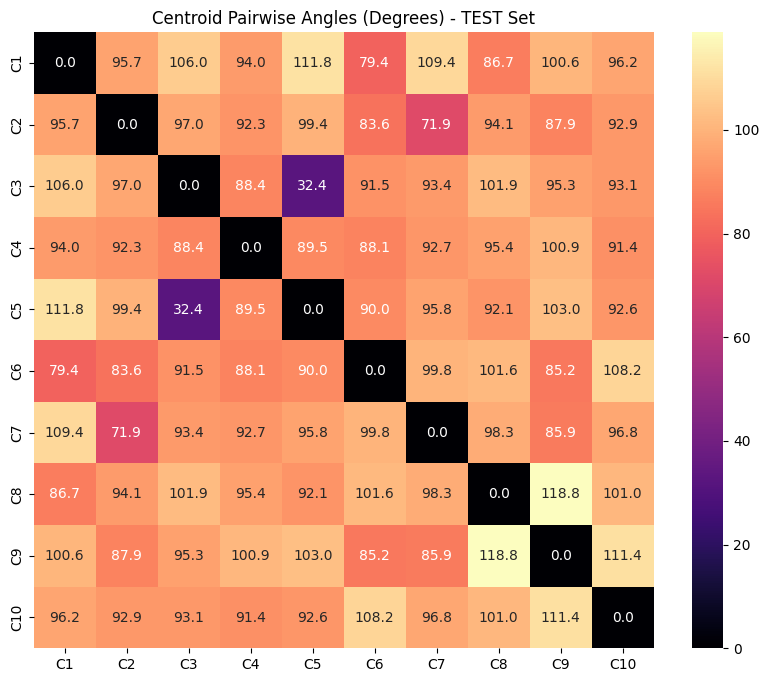

--- TEST Angle Table ---


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
C1,0.000000,95.654900,105.968040,93.951889,111.752663,79.399147,109.409721,86.651520,100.627495,96.209412
C2,95.654900,0.000000,96.972328,92.278145,99.396706,83.646729,71.873642,94.117279,87.922531,92.940674
C3,105.968040,96.972328,0.000000,88.366272,32.358841,91.537682,93.383057,101.862297,95.301231,93.054230
C4,93.951889,92.278145,88.366272,0.000000,89.515648,88.053291,92.725853,95.399178,100.863953,91.437996
C5,111.752663,99.396706,32.358841,89.515648,0.000000,90.040497,95.823921,92.099503,103.049583,92.577805
C6,79.399147,83.646729,91.537682,88.053291,90.040497,0.000000,99.810715,101.562134,85.179436,108.237183
C7,109.409721,71.873642,93.383057,92.725853,95.823921,99.810715,0.000000,98.314316,85.920822,96.780678
C8,86.651520,94.117279,101.862297,95.399178,92.099503,101.562134,98.314316,0.000000,118.841949,100.976814
C9,100.627495,87.922531,95.301231,100.863953,103.049583,85.179436,85.920822,118.841949,0.000000,111.407852
C10,96.209412,92.940674,93.054230,91.437996,92.577805,108.237183,96.780678,100.976814,111.407852,0.000000


In [29]:
for split in ["train", "test"]:
    angles = res[f"{split}_metrics"]['angles']

    angles_df = pd.DataFrame(angles,
                             index=[f"C{i+1}" for i in range(num_classes)],
                             columns=[f"C{i+1}" for i in range(num_classes)])

    plt.figure(figsize=(10, 8))
    sns.heatmap(angles_df, annot=True, fmt=".1f", cmap="magma")
    plt.title(f"Centroid Pairwise Angles (Degrees) - {split.upper()} Set")
    plt.show()

    print(f"--- {split.upper()} Angle Table ---")
    display(angles_df)